In [60]:
import pandas as pd
import ast

In [61]:
# match 데이터는 전부 저런 형식임
# 그렇기 때문에 for loop를 통해 match 데이터들을 수정

In [62]:
# import pandas as pd
# import ast

# file_paths = [
#     '../../collected_data/match-solo-rank.csv',
#     '../../collected_data/match-clan-rank.csv',
#     '../../collected_data/match-normal-individual.csv',
#     '../../collected_data/match-quick-clan.csv'
# ]

# for file_path in file_paths:
#     # 불러오기
#     df = pd.read_csv(file_path)

#     # match 컬럼 문자열을 리스트로 변환
#     df['match'] = df['match'].apply(
#         lambda x: ast.literal_eval(x) if pd.notnull(x) and x != '[]' else []
#     )

#     # explode
#     df_exploded = df.explode('match')

#     # match 딕셔너리를 컬럼으로 확장
#     match_df = pd.json_normalize(df_exploded['match'])

#     
#     match_df['ouid'] = df_exploded['ouid'].values

#     # 덮어쓰기
#     match_df.to_csv(file_path, index=False, encoding='utf-8-sig')

#     print(f"{file_path}")

In [63]:
df_match_solo_rank = pd.read_csv('../../collected_data/match-solo-rank.csv')
df_match_clan_rank = pd.read_csv('../../collected_data/match-clan-rank.csv')
df_match_normal = pd.read_csv('../../collected_data/match-normal-individual.csv')
df_match_quick_clan = pd.read_csv('../../collected_data/match-quick-clan.csv')

In [64]:
df_list = [df_match_normal, df_match_clan_rank, df_match_quick_clan, df_match_solo_rank]

for df in df_list:
    df['date_match'] = pd.to_datetime(df['date_match']).dt.date

In [65]:
df_match_clan_rank.head(1)

,match_id,match_type,match_mode,date_match,match_result,kill,death,assist,ouid
0,2.507270e+17,클랜 랭크전,폭파미션,2025-07-26,1.0,2.0,4.0,1.0,9b2852e25a85deebc5ce4173b1ccc1e6


In [66]:
df_match_normal.head(1)

,match_id,match_type,match_mode,date_match,match_result,kill,death,assist,ouid
0,2.507260e+17,일반전,개인전,2025-07-25,2.0,22.0,29.0,0.0,9b2852e25a85deebc5ce4173b1ccc1e6


In [67]:
df_match_quick_clan.head(1)

,match_id,match_type,match_mode,date_match,match_result,kill,death,assist,ouid
0,2.507292e+17,퀵매치 클랜전,폭파미션,2025-07-29,1.0,12.0,6.0,2.0,9b2852e25a85deebc5ce4173b1ccc1e6


In [68]:
df_match_solo_rank.head(1)

,match_id,match_type,match_mode,date_match,match_result,kill,death,assist,ouid
0,2.507292e+17,랭크전 솔로,폭파미션,2025-07-29,2.0,0.0,3.0,0.0,9b2852e25a85deebc5ce4173b1ccc1e6


C:\Users\user\AppData\Local\Temp\ipykernel_16992\4249063760.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('GnBu_r')


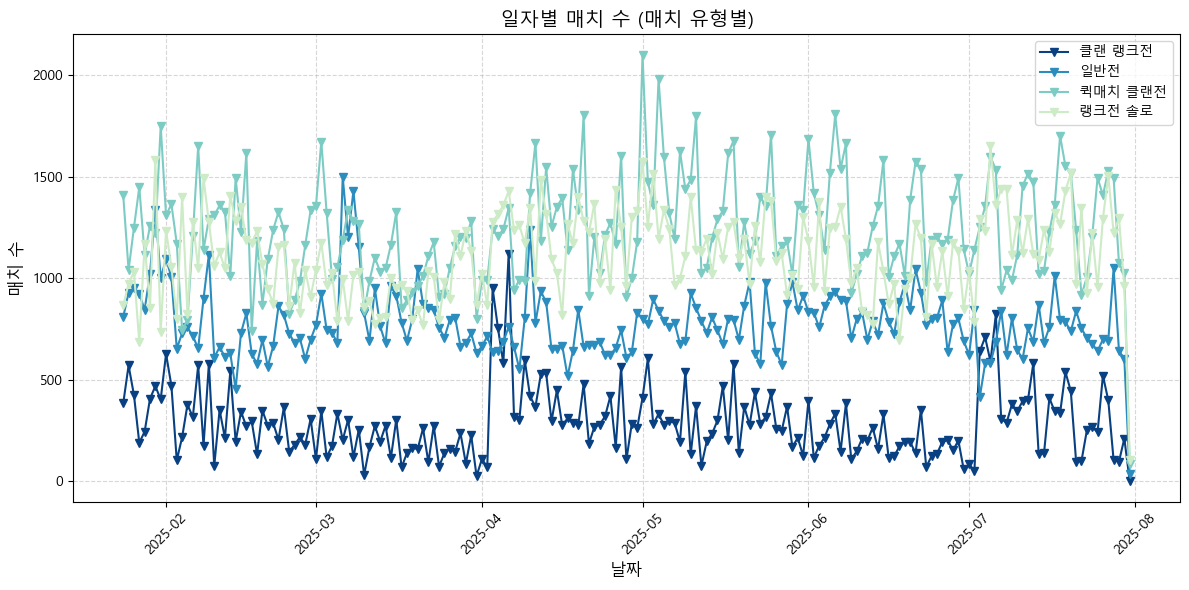

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.font_manager as fm
import matplotlib.colors as mcolors

# 한글 폰트 설정 (Windows 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 매치 데이터프레임과 라벨
df_list = [
    (df_match_clan_rank, '클랜 랭크전'),
    (df_match_normal, '일반전'),
    (df_match_quick_clan, '퀵매치 클랜전'),
    (df_match_solo_rank, '랭크전 솔로')
]

# GnBu 개취
cmap = cm.get_cmap('GnBu_r')
num_lines = len(df_list)
colors = [cmap(i / num_lines) for i in range(num_lines)]

# 그래프 그리기
plt.figure(figsize=(12, 6))

for idx, (df, label) in enumerate(df_list):
    counts = df['date_match'].value_counts().sort_index()
    plt.plot(counts.index, counts.values, marker='v', label=label, color=colors[idx])


plt.title('일자별 매치 수 (매치 유형별)', fontsize=14)
plt.xlabel('날짜', fontsize=12)
plt.ylabel('매치 수', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


C:\Users\user\AppData\Local\Temp\ipykernel_16992\1811062902.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('GnBu_r')


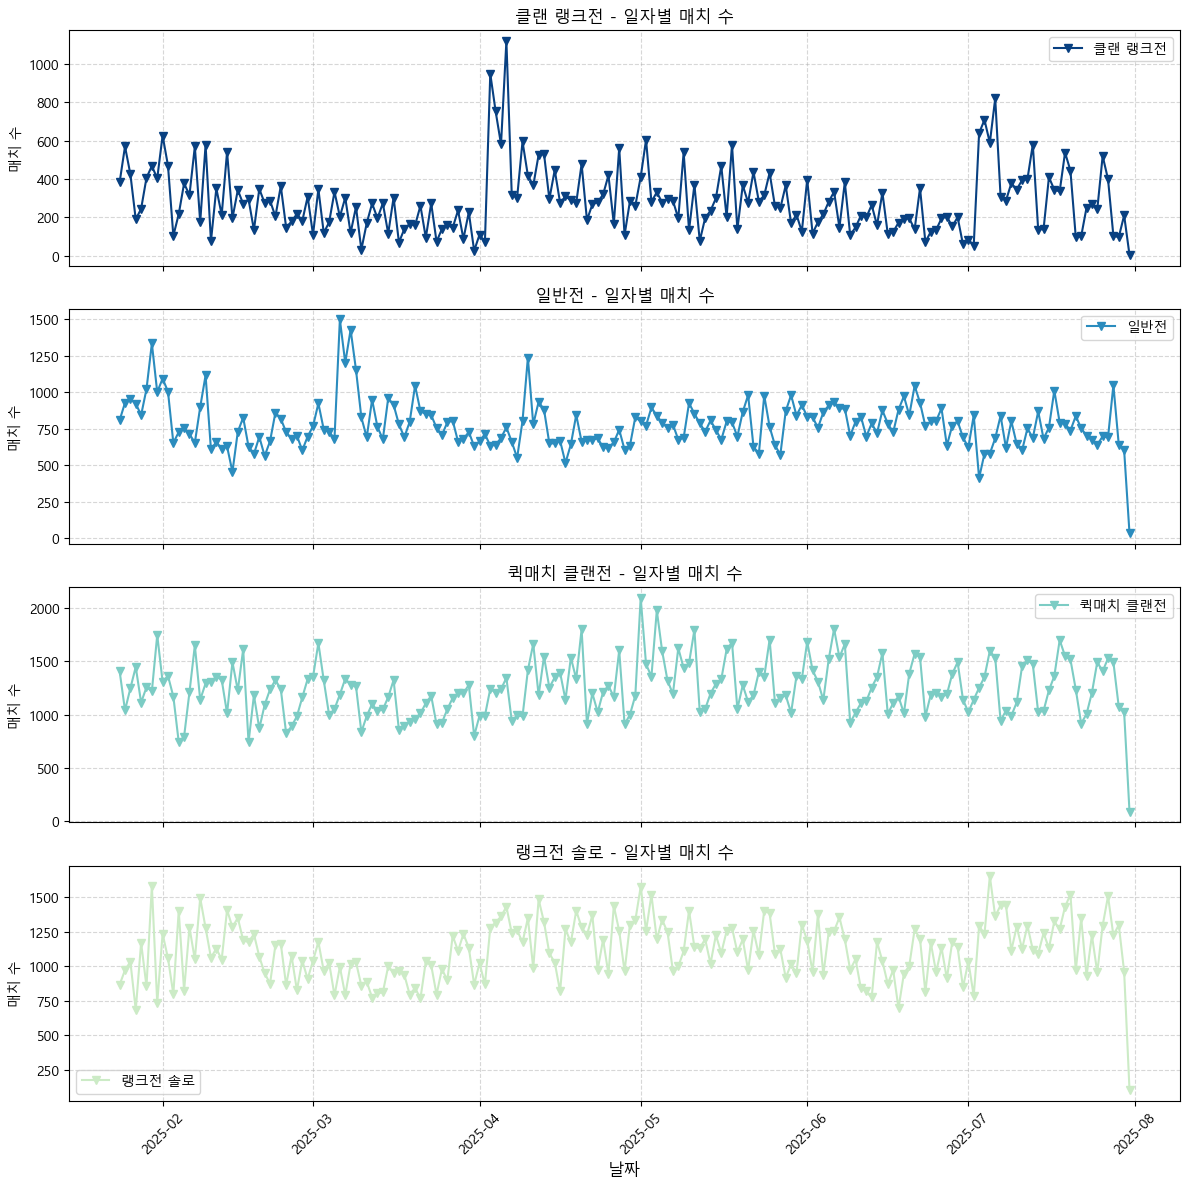

In [77]:
# 서브플롯으로 나눠서 그려보기
n = len(df_list)
fig, axes = plt.subplots(n, 1, figsize=(12, 3 * n), sharex=True)

# 색상 (GnBu로 그려보기 개취)
cmap = cm.get_cmap('GnBu_r')
colors = [cmap(i / n) for i in range(n)]

# 각 그래프 그리기
for idx, (df, label) in enumerate(df_list):
    ax = axes[idx]
    counts = df['date_match'].value_counts().sort_index()
    ax.plot(counts.index, counts.values, color=colors[idx], marker='v', label=label)

    ax.set_title(f"{label} - 일자별 매치 수", fontsize=12)
    ax.set_ylabel('매치 수')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend()

plt.xlabel('날짜', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()